In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
def euler_generalizado(y0,h,ti,tf,f,m):
    N = int(np.ceil((tf - ti) / h))
    t = np.zeros(N + 1)
    U = np.zeros(shape = (m, N + 1))
    t[0] = ti
    U[:, 0] = y0
    for i in range(N):
        U[:, i + 1] = U[:, i] + h*f(t[i], U[:,i])
        t[i + 1] = t[i] + h
    return t,U

def heun_generalizado(y0,h,ti,tf,f,m):
    N = int(np.ceil((tf - ti) / h))
    t = np.zeros(N + 1)
    y = np.zeros(shape = (m, N + 1))
    k1 = np.zeros(m)
    k2 = np.zeros(m)
    t[0] = ti
    y[:, 0] = y0
    for i in range(N):
        k1 = f(t[i],y[: , i])
        k2 = f(t[i],y[: , i] + h*k1)
        y[: ,i + 1] = y[: , i] + (h/2)*(k1 + k2)
        t[i + 1] = t[i] + h

    return t,y

def runge_kutta_generalizado(y0,h,ti,tf,f,m):
    N = int(np.ceil((tf - ti) / h))
    t = np.zeros(N + 1)
    U = np.zeros(shape = (m, N + 1))
    t[0] = ti
    U[:, 0] = y0
    k1 = np.zeros(m)
    k2 = np.zeros(m)
    k3 = np.zeros(m)
    k4 = np.zeros(m)

    for i in range(N):
        k1 = f(t[i],U[:,i])
        k2= f(t[i] + h/2, U[:, i] + (h/2)*k1)
        k3 = f(t[i] + h/2,U[:, i] + (h/2)*k2)
        k4 = f(t[i] + h,U[:, i] + h*k3)
        U[:,i + 1] = U[:, i] + (h/6)*(k1 + 2*k2 + 2*k3 + k4)
        t[i + 1] = t[i] + h
    return t,U

In [6]:
def F(t,U):
    x,y = U[0], U[1]
    eqs = np.array([x - 0.1*x*y, -1.5*y + 0.075*x*y])
    return eqs
y0 = [10,5]

In [7]:
t_runge, y_rk = runge_kutta_generalizado(y0, 0.5, 0, 30, F,2)
t_euler, y_euler = euler_generalizado(y0, 0.1, 0, 30, F,2)
t_heun,y_heun = heun_generalizado(y0,0.5, 0, 30, F,2)

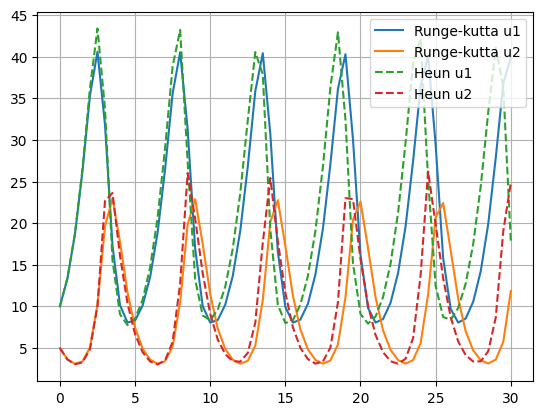

In [8]:
for i in range(len(y_rk)):
    plt.plot(t_runge,y_rk[i], label = f"Runge-kutta u{i + 1}")
for i in range(len(y_euler)):
    plt.plot(t_heun,y_heun[i], label = f"Heun u{i + 1}", linestyle = '--')
plt.grid()
plt.legend()
plt.show()